# Импорт библиотек

In [1]:
import glob
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# Быстрый взгляд на один файл

In [3]:
pd.set_option('display.max_columns', None)

df_sample = pd.read_parquet('train_data/train_data_0.pq')

print(df_sample.shape)
display(df_sample.head())

(1974724, 61)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,5,0,2,8,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,3,0,2,4,6,16,5,4,8,0,1,1,1,1,16,2,17,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0


In [4]:
pd.set_option('display.max_rows', None)  

overview = pd.DataFrame({
    'Признак': df_sample.columns,
    'Тип': df_sample.dtypes.values,
    'Уникальных': df_sample.nunique().values,
    '% Уникальных': (df_sample.nunique() / len(df_sample) * 100).round(2),
    'Пустых': df_sample.isna().sum().values,
    '% Пустых': (df_sample.isna().sum() / len(df_sample) * 100).round(2).values
})

display(overview)

,Признак,Тип,Уникальных,% Уникальных,Пустых,% Пустых
id,id,int64,250000,12.66,0,0.0
rn,rn,int64,51,0.00,0,0.0
pre_since_opened,pre_since_opened,int64,20,0.00,0,0.0
pre_since_confirmed,pre_since_confirmed,int64,18,0.00,0,0.0
pre_pterm,pre_pterm,int64,18,0.00,0,0.0
pre_fterm,pre_fterm,int64,17,0.00,0,0.0
pre_till_pclose,pre_till_pclose,int64,17,0.00,0,0.0
pre_till_fclose,pre_till_fclose,int64,16,0.00,0,0.0
pre_loans_credit_limit,pre_loans_credit_limit,int64,20,0.00,0,0.0
pre_loans_next_pay_summ,pre_loans_next_pay_summ,int64,7,0.00,0,0.0


# Объединение и обработка всех файлов

In [2]:
files = glob.glob('train_data/train_data_*.pq')
agg_chunks = []

for file in files:
    print(f"Обработка {file}")
    df = pd.read_parquet(file)

    # Сортировка
    df = df.sort_values(['id', 'rn']).reset_index(drop=True)

    # Новые признаки:
    # Сумма просрочек, где длительные просрочки штрафуются сильнее
    df['weighted_delinquency'] = (
        df['pre_loans5'] * 1 +
        df['pre_loans530'] * 2 +
        df['pre_loans3060'] * 3 +
        df['pre_loans6090'] * 4 +
        df['pre_loans90'] * 5
    )

    # Какая часть кредитного лимита ещё не выплачена
    df['util_ratio'] = df.apply(
        lambda x: x['pre_loans_outstanding'] / x['pre_loans_credit_limit']
        if x['pre_loans_credit_limit'] != 0 else 0,
        axis=1
    )
    # Отношение следующего платежа к лимиту
    df['pay_limit_ratio'] = df.apply(
        lambda x: x['pre_loans_next_pay_summ'] / x['pre_loans_credit_limit']
        if x['pre_loans_credit_limit'] != 0 else 0,
        axis=1
    )
    # Просрочка к лимиту
    df['maxoverdue_ratio'] = df.apply(
        lambda x: x['pre_loans_max_overdue_sum'] / x['pre_loans_credit_limit']
        if x['pre_loans_credit_limit'] != 0 else 0,
        axis=1
    )

    # Разница между плановым и фактическим сроком кредита
    df['term_diff'] = df['pre_pterm'] - df['pre_fterm']

    # Доля месяцев с хорошей/любой просрочкой по 25‑месячной истории платежей
    paym_cols = [f'enc_paym_{i}' for i in range(25)]
    df['paym_good_ratio'] = (df[paym_cols] == 3).mean(axis=1)
    df['paym_bad_ratio']  = (df[paym_cols] > 0).mean(axis=1)
    # Средний статус за последние 3 месяца 
    df['paym_last3_mean'] = df[paym_cols[:3]].mean(axis=1)
    # За старые 3 месяца 
    df['paym_old3_mean']  = df[paym_cols[-3:]].mean(axis=1)
    # Ухудшается или улучшается платёжная дисциплина
    df['paym_trend']      = df['paym_last3_mean'] - df['paym_old3_mean']
    # 	Максимальная просрочка за последние полгода
    df['paym_last6_max']  = df[paym_cols[:6]].max(axis=1)
    # Разброс статусов 
    df['paym_std_all']    = df[paym_cols].std(axis=1)

    # Агрегация по id 
    agg_dict = {
        'pre_loans5':       ['sum', 'max', 'last'],
        'pre_loans530':     ['sum', 'max', 'last'],
        'pre_loans3060':    ['sum', 'max', 'last'],
        'pre_loans6090':    ['sum', 'max', 'last'],
        'pre_loans90':      ['sum', 'max', 'last'],
        'pre_util':               ['mean', 'max', 'std', 'last'],
        'pre_over2limit':         ['mean', 'max', 'last'],
        'pre_maxover2limit':      ['mean', 'max', 'last'],
        'util_ratio':             ['mean', 'max', 'std', 'last'],
        'pay_limit_ratio':        ['mean', 'max', 'last'],
        'maxoverdue_ratio':       ['mean', 'max', 'last'],
        'pre_loans_outstanding':  ['mean', 'max'],
        'pre_loans_credit_limit': ['mean', 'max', 'last'],
        'pre_loans_next_pay_summ':['mean', 'max', 'last'],
        'pre_loans_credit_cost_rate': ['mean', 'last'],
        'pre_since_opened':       ['mean', 'max', 'std', 'last'],
        'pre_since_confirmed':    ['mean', 'max', 'std', 'last'],
        'pre_pterm':              ['mean', 'max', 'std', 'last'],
        'pre_fterm':              ['mean', 'max', 'std', 'last'],
        'pre_till_pclose':        ['mean', 'max', 'std', 'last'],
        'pre_till_fclose':        ['mean', 'max', 'std', 'last'],
        'weighted_delinquency':  ['sum', 'max', 'mean', 'std'],
        'term_diff':             ['mean', 'std', 'last'],
        'paym_good_ratio':       ['mean', 'last'],
        'paym_bad_ratio':        ['mean', 'last'],
        'paym_last3_mean':       ['mean', 'last'],
        'paym_old3_mean':        ['mean', 'last'],
        'paym_trend':            ['mean', 'last'],
        'paym_last6_max':        ['max', 'mean'],
        'paym_std_all':          ['mean', 'max', 'last'],
        'is_zero_loans5':        ['mean'],
        'is_zero_loans530':      ['mean'],
        'is_zero_loans3060':     ['mean'],
        'is_zero_loans6090':     ['mean'],
        'is_zero_loans90':       ['mean'],
        'is_zero_util':          ['mean'],
        'is_zero_over2limit':    ['mean'],
        'is_zero_maxover2limit': ['mean'],
        'enc_loans_credit_status': ['last'],
        'enc_loans_credit_type':   ['last'],
        'enc_loans_account_holder_type': ['last'],
        'enc_loans_account_cur':   ['last'],
        'pclose_flag':           ['last'],
        'fclose_flag':           ['last'],
        'rn':                    ['count'],
    }

    agg_chunk = df.groupby('id').agg(agg_dict)
    agg_chunk.columns = ['_'.join(col).strip() for col in agg_chunk.columns.values]
    agg_chunk.reset_index(inplace=True)
    agg_chunk.rename(columns={'rn_count': 'loan_count'}, inplace=True)
    agg_chunks.append(agg_chunk)

# Объединение
print("\nОбъединение")
final_df = pd.concat(agg_chunks, ignore_index=True)
print(f"\nРазмер финального датасета: {final_df.shape}")

# Целевая переменная
targets = pd.read_csv('train_target.csv')
final_df = final_df.merge(targets, on='id', how='left')

# Сохранение
final_df.to_parquet('credit_risk.parquet', index=False)
display(final_df.head())

Обработка train_data/train_data_9.pq
Обработка train_data/train_data_11.pq
Обработка train_data/train_data_8.pq
Обработка train_data/train_data_10.pq
Обработка train_data/train_data_3.pq
Обработка train_data/train_data_7.pq
Обработка train_data/train_data_6.pq
Обработка train_data/train_data_2.pq
Обработка train_data/train_data_5.pq
Обработка train_data/train_data_1.pq
Обработка train_data/train_data_0.pq
Обработка train_data/train_data_4.pq

Объединение

Размер финального датасета: (3000000, 107)


,id,pre_loans5_sum,pre_loans5_max,pre_loans5_last,pre_loans530_sum,pre_loans530_max,pre_loans530_last,pre_loans3060_sum,pre_loans3060_max,pre_loans3060_last,...,is_zero_over2limit_mean,is_zero_maxover2limit_mean,enc_loans_credit_status_last,enc_loans_credit_type_last,enc_loans_account_holder_type_last,enc_loans_account_cur_last,pclose_flag_last,fclose_flag_last,loan_count,flag
0,2250000,48,6,6,128,16,16,40,5,5,...,0.875000,0.875000,2,3,1,1,0,0,8,0
1,2250001,12,6,6,32,16,16,10,5,5,...,1.000000,1.000000,2,4,1,1,0,1,2,0
2,2250002,54,6,6,141,16,16,45,5,5,...,0.888889,0.888889,2,3,1,1,0,0,9,0
3,2250003,24,6,6,64,16,16,20,5,5,...,1.000000,1.000000,2,3,1,1,0,0,4,0
4,2250004,6,6,6,13,13,13,5,5,5,...,1.000000,0.000000,3,4,1,1,0,0,1,0


# EDA финального датасета

In [5]:
df = pd.read_parquet('credit_risk.parquet')
df = df.drop('id', axis=1)

In [6]:
duplicates = df.duplicated().sum()
print(f"Дубликатов: {duplicates}")

Дубликатов: 34334


In [7]:
overview = pd.DataFrame({
    'Признак': df.columns,
    'Тип': df.dtypes.values,
    'Уникальных': df.nunique().values,
    '% Уникальных': (df.nunique() / len(df) * 100).round(2),
    'Пустых': df.isna().sum().values,
    '% Пустых': (df.isna().sum() / len(df) * 100).round(2).values
})

display(overview)

,Признак,Тип,Уникальных,% Уникальных,Пустых,% Пустых
pre_loans5_sum,pre_loans5_sum,int64,249,0.01,0,0.00
pre_loans5_max,pre_loans5_max,int64,13,0.00,0,0.00
pre_loans5_last,pre_loans5_last,int64,9,0.00,0,0.00
pre_loans530_sum,pre_loans530_sum,int64,629,0.02,0,0.00
pre_loans530_max,pre_loans530_max,int64,13,0.00,0,0.00
pre_loans530_last,pre_loans530_last,int64,14,0.00,0,0.00
pre_loans3060_sum,pre_loans3060_sum,int64,203,0.01,0,0.00
pre_loans3060_max,pre_loans3060_max,int64,6,0.00,0,0.00
pre_loans3060_last,pre_loans3060_last,int64,7,0.00,0,0.00
pre_loans6090_sum,pre_loans6090_sum,int64,125,0.00,0,0.00


In [9]:
# Пропуски в std признаках заменяю медианой
std_cols = [
    'pre_util_std', 'util_ratio_std', 'pre_since_opened_std',
    'pre_since_confirmed_std', 'pre_pterm_std', 'pre_fterm_std',
    'pre_till_pclose_std', 'pre_till_fclose_std', 'weighted_delinquency_std',
    'term_diff_std'
]

for col in std_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.describe().round(2)

,pre_loans5_sum,pre_loans5_max,pre_loans5_last,pre_loans530_sum,pre_loans530_max,pre_loans530_last,pre_loans3060_sum,pre_loans3060_max,pre_loans3060_last,pre_loans6090_sum,pre_loans6090_max,pre_loans6090_last,pre_loans90_sum,pre_loans90_max,pre_loans90_last,pre_util_mean,pre_util_max,pre_util_std,pre_util_last,pre_over2limit_mean,pre_over2limit_max,pre_over2limit_last,pre_maxover2limit_mean,pre_maxover2limit_max,pre_maxover2limit_last,util_ratio_mean,util_ratio_max,util_ratio_std,util_ratio_last,pay_limit_ratio_mean,pay_limit_ratio_max,pay_limit_ratio_last,maxoverdue_ratio_mean,maxoverdue_ratio_max,maxoverdue_ratio_last,pre_loans_outstanding_mean,pre_loans_outstanding_max,pre_loans_credit_limit_mean,pre_loans_credit_limit_max,pre_loans_credit_limit_last,pre_loans_next_pay_summ_mean,pre_loans_next_pay_summ_max,pre_loans_next_pay_summ_last,pre_loans_credit_cost_rate_mean,pre_loans_credit_cost_rate_last,pre_since_opened_mean,pre_since_opened_max,pre_since_opened_std,pre_since_opened_last,pre_since_confirmed_mean,pre_since_confirmed_max,pre_since_confirmed_std,pre_since_confirmed_last,pre_pterm_mean,pre_pterm_max,pre_pterm_std,pre_pterm_last,pre_fterm_mean,pre_fterm_max,pre_fterm_std,pre_fterm_last,pre_till_pclose_mean,pre_till_pclose_max,pre_till_pclose_std,pre_till_pclose_last,pre_till_fclose_mean,pre_till_fclose_max,pre_till_fclose_std,pre_till_fclose_last,weighted_delinquency_sum,weighted_delinquency_max,weighted_delinquency_mean,weighted_delinquency_std,term_diff_mean,term_diff_std,term_diff_last,paym_good_ratio_mean,paym_good_ratio_last,paym_bad_ratio_mean,paym_bad_ratio_last,paym_last3_mean_mean,paym_last3_mean_last,paym_old3_mean_mean,paym_old3_mean_last,paym_trend_mean,paym_trend_last,paym_last6_max_max,paym_last6_max_mean,paym_std_all_mean,paym_std_all_max,paym_std_all_last,is_zero_loans5_mean,is_zero_loans530_mean,is_zero_loans3060_mean,is_zero_loans6090_mean,is_zero_loans90_mean,is_zero_util_mean,is_zero_over2limit_mean,is_zero_maxover2limit_mean,enc_loans_credit_status_last,enc_loans_credit_type_last,enc_loans_account_holder_type_last,enc_loans_account_cur_last,pclose_flag_last,fclose_flag_last,loan_count,flag
count,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00,3000000.00
mean,52.10,6.01,5.99,138.42,16.02,15.95,43.62,5.01,5.00,34.88,4.00,4.00,69.80,8.03,8.00,13.32,16.07,4.07,10.63,2.21,3.25,2.12,15.71,16.91,16.34,0.52,1.54,0.51,0.49,0.45,1.46,0.52,0.36,1.04,0.35,3.00,3.87,9.68,16.06,9.50,2.42,4.27,2.68,4.62,5.29,9.33,15.88,5.44,10.68,8.21,13.61,4.23,8.00,8.27,14.31,5.04,8.00,8.36,13.35,4.06,8.42,6.92,13.00,4.92,6.76,8.59,12.74,3.83,9.25,948.30,109.20,108.76,0.69,-0.08,6.28,-0.42,0.44,0.62,0.59,0.75,0.36,0.65,2.77,3.16,-2.41,-2.51,2.52,1.04,1.14,1.54,1.11,0.92,0.84,0.96,0.97,0.97,0.63,0.93,0.86,2.19,3.42,1.04,1.00,0.25,0.48,8.72,0.04
std,36.96,0.28,0.28,98.14,0.33,0.70,30.89,0.19,0.07,24.70,0.01,0.02,49.42,0.42,0.13,2.69

In [11]:
columns = df.columns.to_list()

for col in columns:
    print(f'\n{col}')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    print(f'Границы: [{low:.2f} | {high:.2f}]')

    outliers = df[(df[col] < low) | (df[col] > high)]
    print('Выбросы:', len(outliers))
    print(f'% Выбросов: {len(outliers) / len(df) * 100:.2f}')


pre_loans5_sum
Границы: [-48.00 | 144.00]
Выбросы: 49609
% Выбросов: 1.65

pre_loans5_max
Границы: [6.00 | 6.00]
Выбросы: 4057
% Выбросов: 0.14

pre_loans5_last
Границы: [6.00 | 6.00]
Выбросы: 8548
% Выбросов: 0.28

pre_loans530_sum
Границы: [-128.00 | 384.00]
Выбросы: 49416
% Выбросов: 1.65

pre_loans530_max
Границы: [16.00 | 16.00]
Выбросы: 42900
% Выбросов: 1.43

pre_loans530_last
Границы: [16.00 | 16.00]
Выбросы: 27513
% Выбросов: 0.92

pre_loans3060_sum
Границы: [-40.00 | 120.00]
Выбросы: 50566
% Выбросов: 1.69

pre_loans3060_max
Границы: [5.00 | 5.00]
Выбросы: 12583
% Выбросов: 0.42

pre_loans3060_last
Границы: [5.00 | 5.00]
Выбросы: 1541
% Выбросов: 0.05

pre_loans6090_sum
Границы: [-32.00 | 96.00]
Выбросы: 50452
% Выбросов: 1.68

pre_loans6090_max
Границы: [4.00 | 4.00]
Выбросы: 17
% Выбросов: 0.00

pre_loans6090_last
Границы: [4.00 | 4.00]
Выбросы: 141
% Выбросов: 0.00

pre_loans90_sum
Границы: [-64.00 | 192.00]
Выбросы: 50613
% Выбросов: 1.69

pre_loans90_max
Границы: [8.00 

In [12]:
total = len(df['flag'])
count_0 = (df['flag'] == 0).sum()
count_1 = (df['flag'] == 1).sum()

print(df['flag'].value_counts())
print()

print(f'Процент 0: {count_0 / total * 100:.2f}%')
print(f'Процент 1: {count_1 / total * 100:.2f}%')

flag
0    2893558
1     106442
Name: count, dtype: int64

Процент 0: 96.45%
Процент 1: 3.55%


# Моделирование

##  Обучение Random Forest и определение важности признаков

In [13]:
X = df.drop('flag', axis=1)
y = df['flag']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [15]:
print('Определение важности признаков')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print('Результат:')
display(importances)

Определение важности признаков
Результат:


,feature,importance
78,paym_bad_ratio_mean,1.000209e-01
92,is_zero_loans530_mean,6.849177e-02
87,paym_last6_max_mean,5.789436e-02
80,paym_last3_mean_mean,5.445960e-02
81,paym_last3_mean_last,5.373510e-02
93,is_zero_loans3060_mean,5.186529e-02
76,paym_good_ratio_mean,4.193449e-02
82,paym_old3_mean_mean,3.085528e-02
96,is_zero_util_mean,2.981709e-02
85,paym_trend_last,2.934825e-02


In [16]:
# После анализа принимаю решение об удалении 
# признаков с малой важностью

df = df.drop(columns=['pre_loans6090_max'])

In [25]:
X = df.drop('flag', axis=1)
y = df['flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=50000, random_state=42, stratify=y_train
)

In [26]:
pipelines = {
    'LightGBM': Pipeline([
        ('clf', LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1))
    ]),
    'CatBoost': Pipeline([
        ('clf', CatBoostClassifier(eval_metric='AUC', thread_count=-1, verbose=0, random_state=42))
    ])
}

In [27]:
scale_pos_weight = round(len(y_train[y_train==0]) / len(y_train[y_train==1]))

param_grid = {
    'LightGBM': [
        {
            'clf__n_estimators': [2000],
            'clf__learning_rate': [0.01, 0.02],
            'clf__max_depth': [8, 10],
            'clf__num_leaves': [63, 127],
            'clf__scale_pos_weight': [scale_pos_weight],  
            'clf__subsample': [0.8],
            'clf__colsample_bytree': [0.8],
            'clf__reg_alpha': [0.5],
            'clf__reg_lambda': [2.0],
            'clf__min_child_samples': [20]
        }
    ],
    'CatBoost': [
        {
            'clf__n_estimators': [2000],
            'clf__learning_rate': [0.02],
            'clf__max_depth': [6, 8],
            'clf__auto_class_weights': ['Balanced', 'SqrtBalanced'],  
            'clf__l2_leaf_reg': [3]
        }
    ]
}

In [28]:
best_score = 0
best_pipeline = None
best_name = ''
best_params = None

for name, pipe in pipelines.items():
    print(f"\nПодбор для {name}")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid[name],
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_sample, y_sample)
    print(f"Лучший ROC-AUC (CV): {grid.best_score_:.4f}")
    print(f"Лучшие параметры: {grid.best_params_}")
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_pipeline = grid.best_estimator_
        best_name = name
        best_params = grid.best_params_

print(f"\nЛучшая модель: {best_name}, ROC-AUC CV: {best_score:.2f}")
print(f"Параметры: {best_params}")


Подбор для LightGBM
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучший ROC-AUC (CV): 0.6689
Лучшие параметры: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 2000, 'clf__num_leaves': 127, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 2.0, 'clf__scale_pos_weight': 27, 'clf__subsample': 0.8}

Подбор для CatBoost
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучший ROC-AUC (CV): 0.6711
Лучшие параметры: {'clf__auto_class_weights': 'SqrtBalanced', 'clf__l2_leaf_reg': 3, 'clf__learning_rate': 0.02, 'clf__max_depth': 6, 'clf__n_estimators': 2000}

Лучшая модель: CatBoost, ROC-AUC CV: 0.67
Параметры: {'clf__auto_class_weights': 'SqrtBalanced', 'clf__l2_leaf_reg': 3, 'clf__learning_rate': 0.02, 'clf__max_depth': 6, 'clf__n_estimators': 2000}


In [29]:
best_pipeline.fit(X_train, y_train)

y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC на тесте: {auc:.2f}")

ROC-AUC на тесте: 0.75


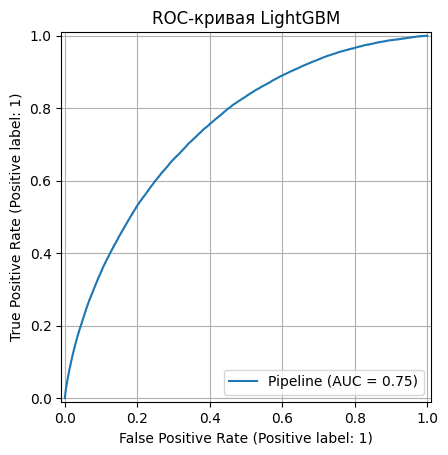

In [30]:
# Визуализация
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test)
plt.title('ROC-кривая LightGBM')
plt.grid(True)
plt.show()

In [34]:
# Сохранение результатов
with open('credit_risk_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

pd.DataFrame({'probability': y_pred_proba}).to_csv('test_predictions.csv', index=False)